In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

# Load cleaned data
new_products = pd.read_csv("/Users/wengel/230A_final_project/code/new_products.csv")
new_products.shape

(5056, 35)

In [10]:
m4 = smf.ols(
    """log_price ~ C(primary_category, Treatment('Skincare'))
                + sephora_exclusive + limited_edition + online_only + new
                + size_ml + size_count
                + has_retinol + has_niacinamide + has_hyaluronic
                + has_vitamin_c + has_aha_bha + has_peptides
                + has_spf + has_fragrance + has_ceramides + has_vitamin_e""",
    data=new_products
).fit(cov_type="HC2")

print(m4.summary())



                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     88.86
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        01:17:06   Log-Likelihood:                -4547.1
No. Observations:                5056   AIC:                             9138.
Df Residuals:                    5034   BIC:                             9282.
Df Model:                          21                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

## M4 Model Summary — Key Observations

**Significant predictors (p < 0.05):**
- All primary categories are significant relative to Skincare baseline
- Fragrance is the most expensive category — associated with higher prices than Skincare
- `Bath & Body`, `Hair`, `Makeup`, and `Other` are all cheaper than Skincare
- `sephora_exclusive` is negative and significant : exclusive products are surprisingly associated with *lower* prices
- `size_ml` is positive and significant — larger products cost more as expected

**Non-significant predictors (p > 0.05):**
- `limited_edition`, `online_only`, and `new` — none of these marketing flags significantly affect price

**sephora_exclusive:**
The negative coefficient is counterintuitive and worth investigating further in diagnostics — could be driven by influential points or a specific category pulling the estimate down.


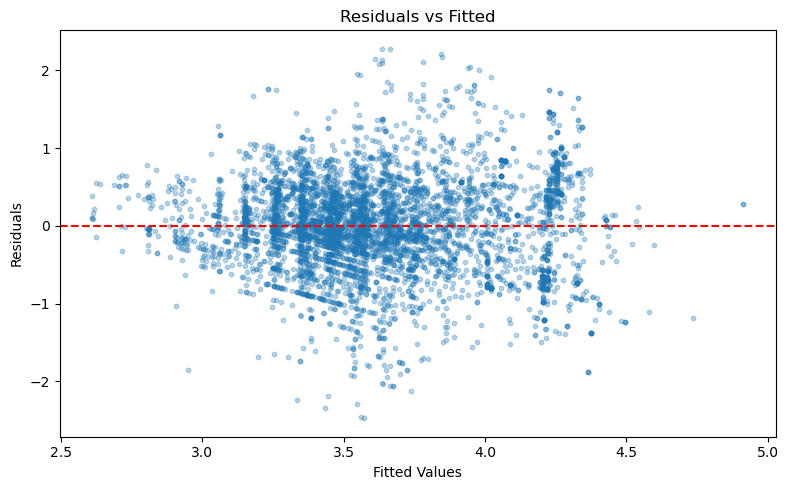

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(m4.fittedvalues, m4.resid, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

## Residuals vs Fitted
**Linearity** Residuals appear randomly scattered around zero , linearity assumption is reasonably met. 
However, there is a slight fan shape,  mild **heteroscedasticity** (unequal variance), which justifies the use of (HC2/HC3).

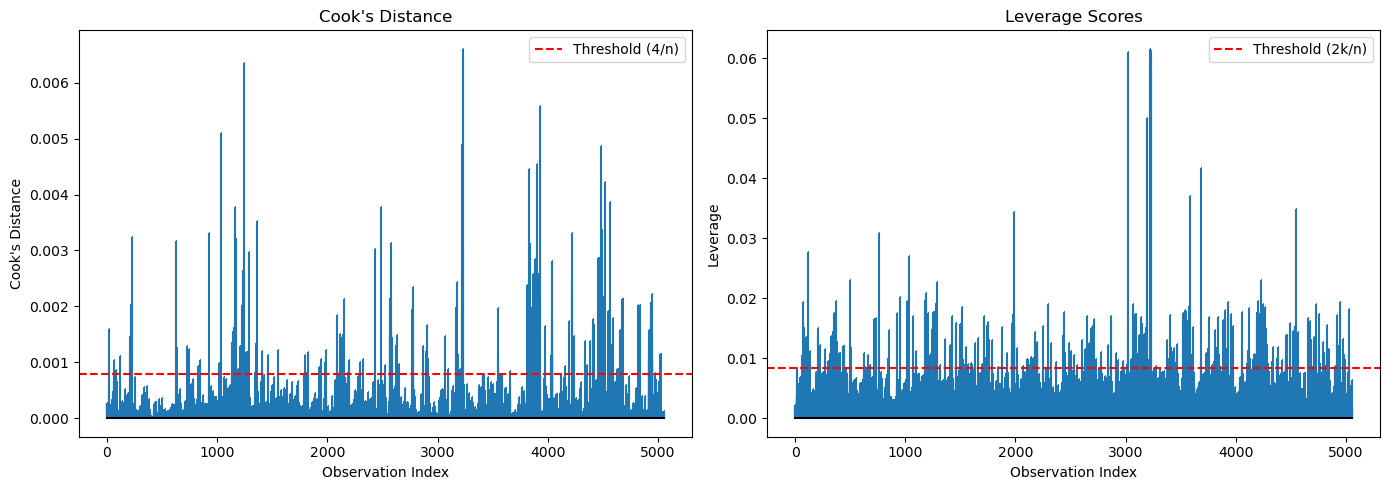

In [12]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(m4)
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cook's Distance
axes[0].stem(range(len(cooks_d)), cooks_d, markerfmt=",", linefmt="C0-", basefmt="k-")
axes[0].axhline(4/len(cooks_d), color='red', linestyle='--', label=f"Threshold (4/n)")
axes[0].set_xlabel("Observation Index")
axes[0].set_ylabel("Cook's Distance")
axes[0].set_title("Cook's Distance")
axes[0].legend()

# Leverage
axes[1].stem(range(len(leverage)), leverage, markerfmt=",", linefmt="C0-", basefmt="k-")
axes[1].axhline(2 * m4.df_model / len(leverage), color='red', linestyle='--', label="Threshold (2k/n)")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Leverage")
axes[1].set_title("Leverage Scores")
axes[1].legend()

plt.tight_layout()
plt.show()

Highest Cook's distance observed is below the 0.5 threshold, no single observation is meaningfully changing the regression estimates. 
 some observations exceed the leverage threshold of 2k/n, their elevated leverage alone does not create huge influence unless paired with large residuals. High leverage points exist in the data, but not severely influential enough to affect the validity of the model's estimates. 
  with n = 5056, HC2 and HC3 are asymptotically equivalent — individual leverage values become sufficiently small that both correction factors converge, making HC2 a justified and appropriate choice for robust standard error estimation.

In [13]:
# Check for large residuals
residuals = m4.resid
std_residuals = m4.resid / m4.resid.std()

print(f"Residuals beyond ±2 std: {(abs(std_residuals) > 2).sum()} ({(abs(std_residuals) > 2).mean():.1%})")
print(f"Residuals beyond ±3 std: {(abs(std_residuals) > 3).sum()} ({(abs(std_residuals) > 3).mean():.1%})")
print(f"\nMax residual: {residuals.max():.3f}")
print(f"Min residual: {residuals.min():.3f}")

Residuals beyond ±2 std: 268 (5.3%)
Residuals beyond ±3 std: 50 (1.0%)

Max residual: 2.279
Min residual: -2.474


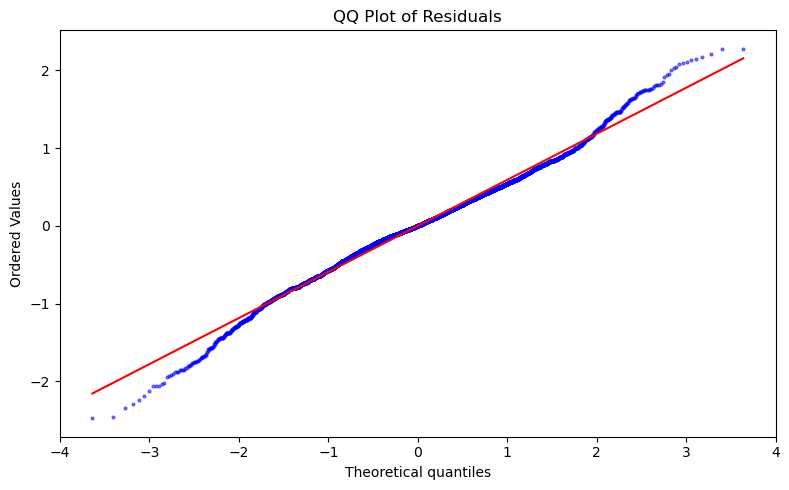

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
stats.probplot(m4.resid, dist="norm", plot=ax)
ax.get_lines()[0].set(color='blue', markersize=2, alpha=0.5)
ax.get_lines()[1].set(color='red')
ax.set_title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

with the data size we have (n is large), so we can even just cite CLT for normality of residuals. Therefore, the slight tail deviation isnt a concern.

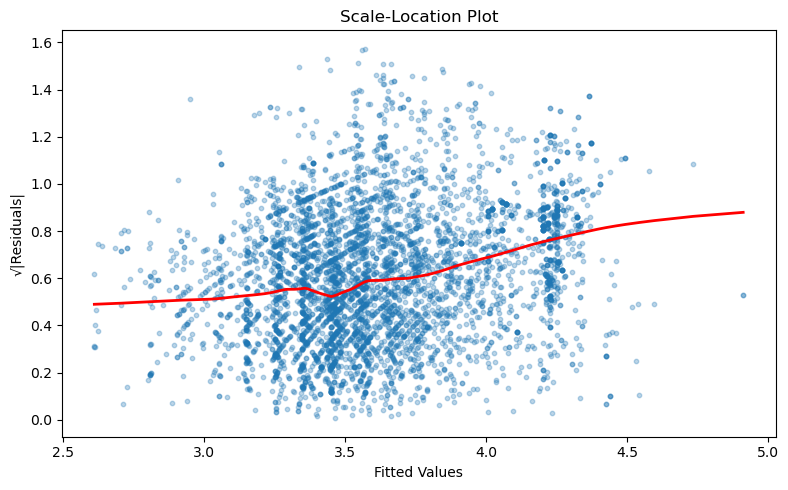

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(m4.fittedvalues, np.sqrt(np.abs(m4.resid)), alpha=0.3, s=10)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("√|Residuals|")
ax.set_title("Scale-Location Plot")

# add a smoothed line to see the trend
from statsmodels.nonparametric.smoothers_lowess import lowess
smoothed = lowess(np.sqrt(np.abs(m4.resid)), m4.fittedvalues, frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2)

plt.tight_layout()
plt.show()

## Scale-Location Plot

The smoothed red line shows a gentle upward slope, confirming mild heteroscedasticity. consistent with the residuals vs fitted plot 
justifies use of robust standard errors. 

## Quick Summary for Diagnostics


Model diagnostics confirm that linearity and approximate normality assumptions are reasonably met. Mild heteroscedasticity is present, justifying the use of 
robust standard errors. No observations are severely influential, and with n = 5056, HC2 is an appropriate and sufficient choice for robust standard error 
estimation given its asymptotic equivalence to HC3 at large sample sizes.